  [fkv] step     0 | -ELBO 2.1497 | alpha=0.699  beta=0.300 | wait 0
  [fkv] step   200 | -ELBO 0.5824 | alpha=0.589  beta=0.219 | wait 0
  [fkv] step   400 | -ELBO -0.0124 | alpha=0.823  beta=0.084 | wait 0
  [fkv] step   600 | -ELBO -0.5295 | alpha=0.859  beta=0.057 | wait 0
  [fkv] step   800 | -ELBO -0.8907 | alpha=0.840  beta=0.049 | wait 4
  [fkv] step  1000 | -ELBO -1.0822 | alpha=0.835  beta=0.046 | wait 0
  [fkv] step  1200 | -ELBO -1.1155 | alpha=0.835  beta=0.046 | wait 2
  [fkv] step  1400 | -ELBO -1.1180 | alpha=0.835  beta=0.046 | wait 4
  [fkv] step  1600 | -ELBO -1.1183 | alpha=0.835  beta=0.046 | wait 42
  [fkv] step  1800 | -ELBO -1.1184 | alpha=0.835  beta=0.046 | wait 73
  [fkv] step  2000 | -ELBO -1.1184 | alpha=0.835  beta=0.046 | wait 2
  [fkv] step  2200 | -ELBO -1.1184 | alpha=0.835  beta=0.046 | wait 202
  [fkv] step  2400 | -ELBO -1.1185 | alpha=0.835  beta=0.046 | wait 402
  [fkv] step  2600 | -ELBO -1.1186 | alpha=0.835  beta=0.046 | wait 172
  [fkv] step  

PosixPath('photopolymer_kelvinvoigt_fit')

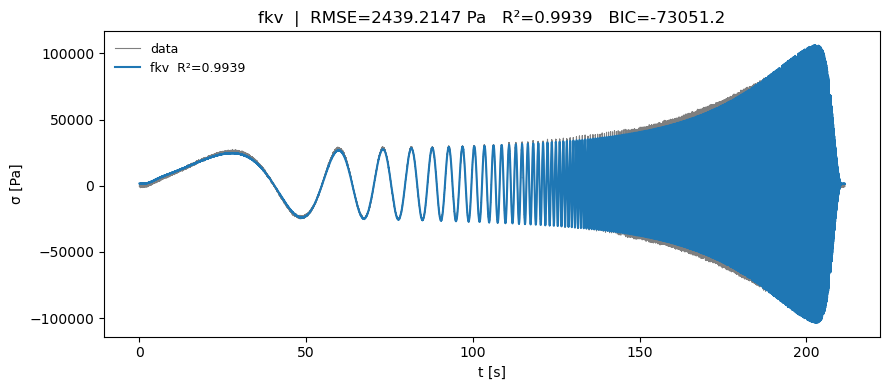

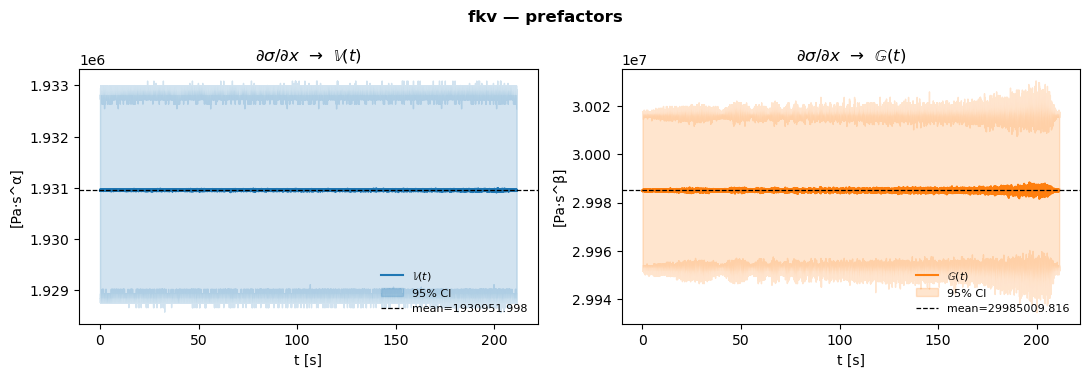

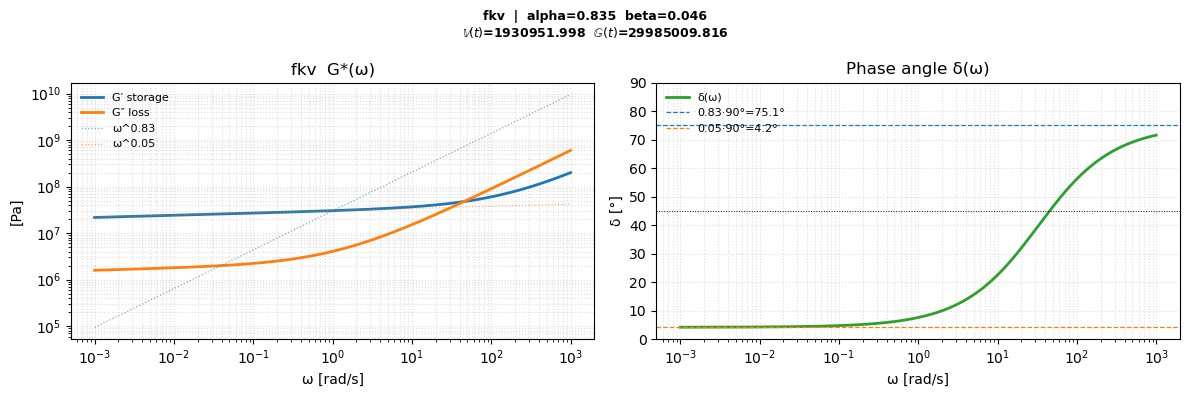

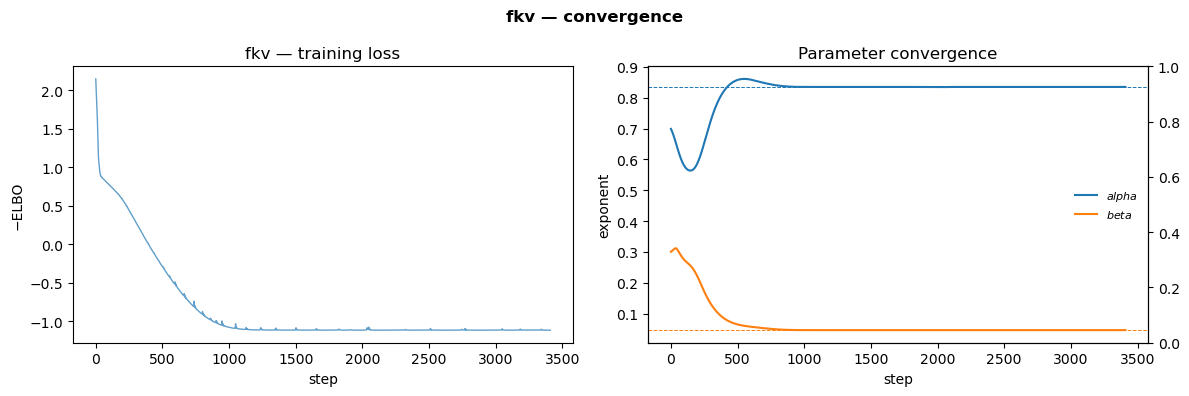

In [1]:
from rheogp import SPGP
from rheogp.utils import compare_models
import pandas as pd
import numpy as np
from pathlib import Path

file_path = Path.cwd().parent / "demos" / "data" / "photopolymer_50C_chirp.xlsx"
df = pd.read_excel(file_path)

omega_min = 0.001
omega_max = 2000

t = df.iloc[:, 0].values.astype(np.float32)  
strain = df.iloc[:, 1].values.astype(np.float32)
stress = df.iloc[:, 2].values.astype(np.float32) 

model = SPGP(model="fkv", kernel="linear",
                                           #   (keep kernel="rbf" for identical-to-before behavior)
             convolution="causal",         # NEW: or "steady" if your chirp is windowed
             quadrature="exact",           # NEW default (use "left" to reproduce v0.1 numbers)
             inducing_points=300, learning_rate=0.005, learning_rate_physics=0.005,
             omega_min=0.001, omega_max=1000, n_epochs=20000)

model.fit(t, strain, stress)

print(model.summary())           # BIC, RMSE, R², all params with CI
sigma_pred, sigma_std = model.predict(strain, return_std=True)

model.plot_fit()
model.plot_prefactors()
model.plot_Gstar()
model.plot_convergence()

# NEW: everything as plain numpy, for your own paper figures
res = model.results()
res.t, res.prediction, res.prediction_std   # fit ± σ
res.features, res.feature_names             # physical features x_i(t)
res.sensitivities["V"]["mean"]             # time-resolved prefactor + CI bands
res.sensitivities["G_bb"]["mean"]             # time-resolved prefactor + CI bands
res.omega, res.Gp, res.Gdp                  # model G', G''
res.metrics["aic"], res.metrics["bic"]      # information criteria
res.save("photopolymer_kelvinvoigt_fit")            # → .npz + .json, reload with FitResult.load()

0.00088819995
0.000935328810480773


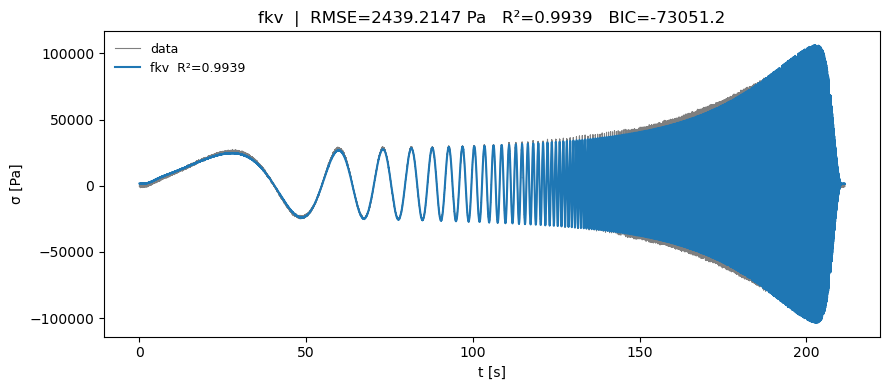

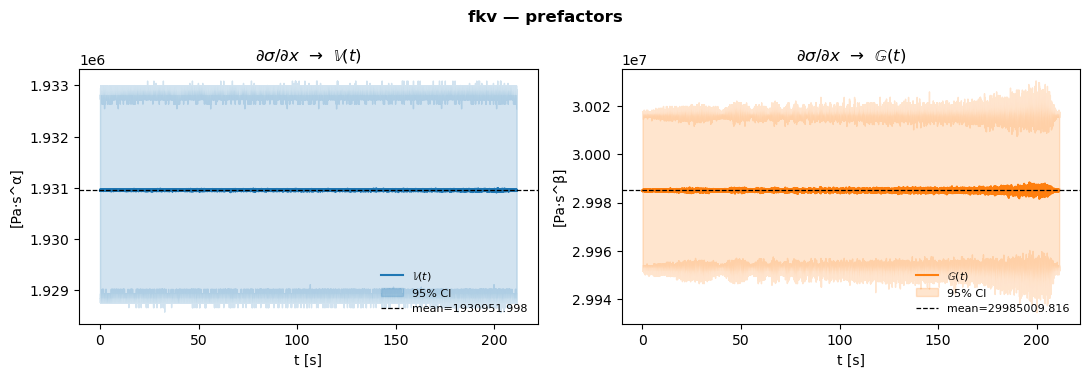

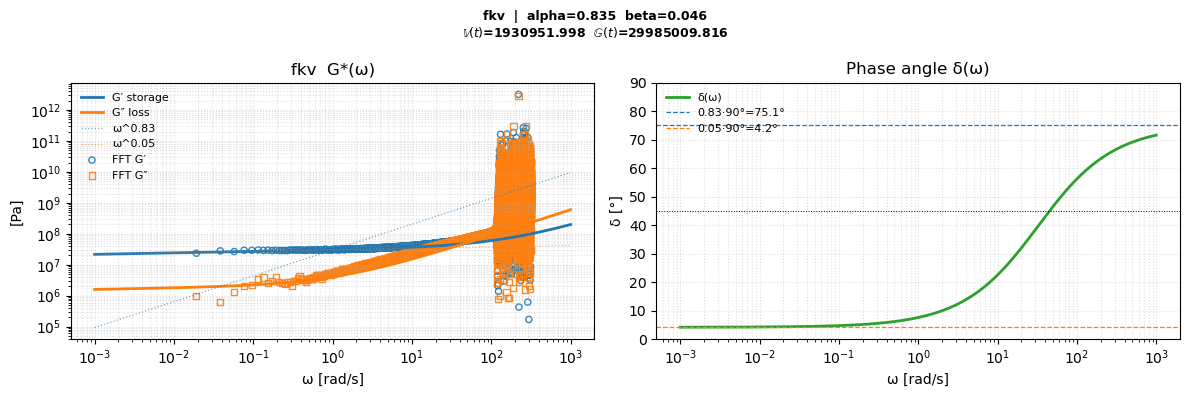

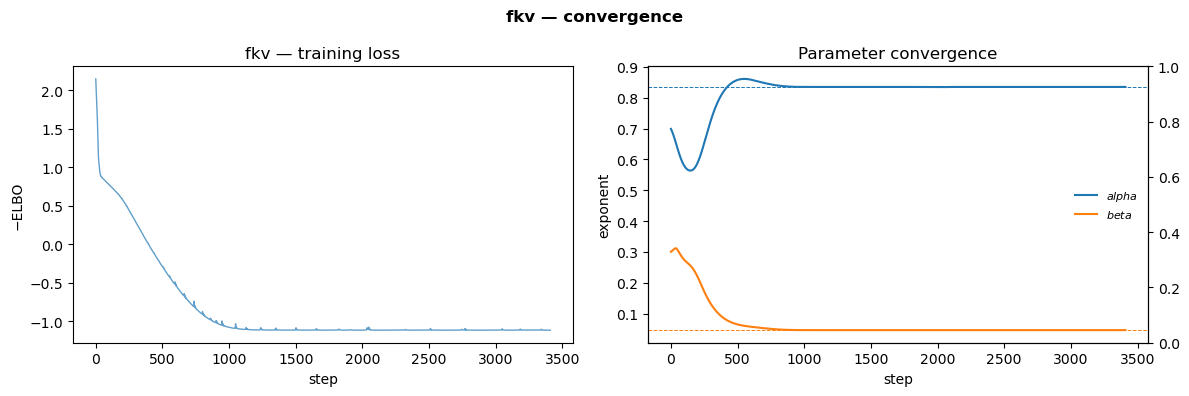

In [2]:
sigma_pred = model.predict(strain)
sigma_pred, sigma_std = model.predict(strain, return_std=True)
print(np.max(strain))
model.plot_fit()
model.plot_prefactors()          # V(t) and G(t) with 95% CI
model.plot_Gstar(add_fft=True)               # G′, G″, phase angle
model.plot_convergence()

tau_c =  (28222.7771 / 28635783.6458)**(1/(1-0.007502837106585503))
print(tau_c)
# compare all three models in one call
#best = compare_models({"SP": sp, "FKV": fkv, "FMM": fmm})

talpha  = 0.8349 s
V     = 1930951.9980 Pa
95% CI = [1928587.0838, 1932910.8575] Pa
G     = 29985009.8157 Pa
95% CI = [29948293.4932, 30017663.6277] Pa
sy = 31143.2223 Pa  |  sm = 3222.4103 Pa
Pre-step baseline: -16831.966973 Pa
After offset removal — range: [-0.0608, 622370.1811] Pa


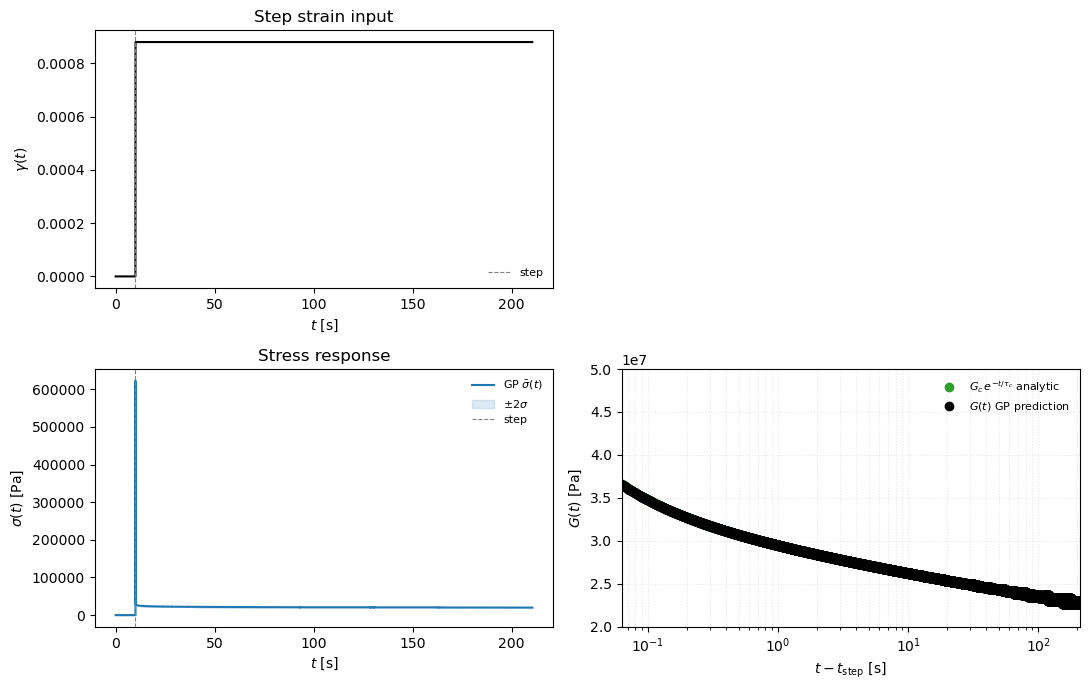

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ── parameters from the Maxwell model ───────────────────────
alpha  = model.gp_model_.phys.named_phys_params()["alpha"]
beta  = model.gp_model_.phys.named_phys_params()["beta"]
V     = model.prefactors_["V"]["scalar_mean"]
V_lo  = model.prefactors_["V"]["scalar_lower"]
V_hi  = model.prefactors_["V"]["scalar_upper"]

G     = model.prefactors_["G_bb"]["scalar_mean"]
G_lo  = model.prefactors_["G_bb"]["scalar_lower"]
G_hi  = model.prefactors_["G_bb"]["scalar_upper"]
print(f"talpha  = {alpha:.4f} s")
print(f"V     = {V:.4f} Pa")
print(f"95% CI = [{V_lo:.4f}, {V_hi:.4f}] Pa")
print(f"G     = {G:.4f} Pa")
print(f"95% CI = [{G_lo:.4f}, {G_hi:.4f}] Pa")

# ── scalers ──────────────────────────────────────────────────
sy = float(model.scaler_y_.scale_[0])   # σ_y
sm = float(model.scaler_y_.mean_[0])    # μ_y  ← the offset
print(f"sy = {sy:.4f} Pa  |  sm = {sm:.4f} Pa")

# ── step strain with 1s wait before step ────────────────────
dt_step     = 1 / 1000
t_end       = 1 + (2 * np.pi / (1* 0.03))
t_step      = np.arange(0.0, t_end, dt_step)
gamma_0     = 8.8e-4
t_step_on   = 10
step_strain = np.zeros_like(t_step)
step_strain[t_step >= t_step_on] = gamma_0
#step_strain += np.random.randn(len(t_step)) * gamma_0 * 1e-8  # tiny noise

# ── predict ──────────────────────────────────────────────────
sigma_step, sigma_step_std = model.predict(
    step_strain, time=t_step, return_std=True
)

# remove sm offset — unphysical for step strain
# (sm is the training stress mean added back by StandardScaler)
# ── zero baseline from pre-step region ──────────────────────
mask_pre    = t_step < t_step_on
baseline    = sigma_step[mask_pre].mean()
baseline_std    = sigma_step_std[mask_pre].mean()

print(f"Pre-step baseline: {baseline:.6f} Pa")

sigma_step  = sigma_step - baseline
sigma_step_std = sigma_step_std - baseline_std
print(f"After offset removal — range: [{sigma_step.min():.4f}, {sigma_step.max():.4f}] Pa")

from scipy.special import gamma as sc_gamma
# ── analytic G(t) for Maxwell ────────────────────────────────
mask_relax    = t_step > (t_step_on + dt_step)
t_relax       = t_step[mask_relax] - t_step_on
G_analytic    = G * t_relax**(-beta) / sc_gamma(1 - beta) + V * t_relax**(-alpha) / sc_gamma(1 - alpha)
G_analytic_lo = G_lo * t_relax**(-beta) / sc_gamma(1 - beta) + V_lo * t_relax**(-alpha) / sc_gamma(1 - alpha)
G_analytic_hi = G_hi * t_relax**(-beta) / sc_gamma(1 - beta) + V_hi * t_relax**(-alpha) / sc_gamma(1 - alpha)

# ── figure: 2×2 layout ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# top-left: strain
ax = axes[0, 0]
ax.plot(t_step, step_strain, color="black", lw=1.5)
ax.axvline(t_step_on, color="gray", lw=0.8, ls="--", label="step")
ax.set_xlabel("$t$ [s]")
ax.set_ylabel(r"$\gamma(t)$")
ax.set_title("Step strain input")
ax.legend(fontsize=8, frameon=False)
ax.grid(False)

# top-right: off
axes[0, 1].axis("off")

# bottom-left: stress
ax = axes[1, 0]
ax.plot(t_step, sigma_step, color="tab:blue", lw=1.5,
        label=r"GP $\bar{\sigma}(t)$")
ax.fill_between(t_step,
                sigma_step - 1.96 * (sigma_step_std),
                sigma_step + 1.96 * (sigma_step_std),
                color="tab:blue", alpha=0.15, label=r"$\pm 2\sigma$")
ax.axvline(t_step_on, color="gray", lw=0.8, ls="--", label="step")
ax.set_xlabel("$t$ [s]")
ax.set_ylabel(r"$\sigma(t)$ [Pa]")
ax.set_title("Stress response")
ax.legend(fontsize=8, frameon=False)
ax.grid(False)

# bottom-right: relaxation modulus
ax = axes[1, 1]
mask_gp = t_step > (t_step_on + dt_step)
t_gp    = t_step[mask_gp] - t_step_on
G_gp    = sigma_step[mask_gp] / gamma_0
G_gp_lo = (sigma_step[mask_gp] - 1.96 * (sigma_step_std[mask_gp] )) / gamma_0
G_gp_hi = (sigma_step[mask_gp] + 1.96 * (sigma_step_std[mask_gp] )) / gamma_0

ax.fill_between(t_relax, G_analytic_lo, G_analytic_hi,
                color="tab:green", alpha=0.15)
ax.plot(t_relax, G_analytic, "o", color="tab:green", lw=2.0,
        label=r"$G_c\,e^{-t/\tau_c}$ analytic")
ax.fill_between(t_gp, G_gp_lo, G_gp_hi,
                color="tab:blue", alpha=0.15)
ax.plot(t_gp, G_gp, "o",color="k",
        label=r"$G(t)$ GP prediction")
ax.set_xscale("log")
ax.set_xlim(2*np.pi/100, 2*np.pi/0.03)
ax.set_yscale("linear")
ax.set_ylim(0.2e8, 0.5e8)
ax.set_xlabel(r"$t - t_{\mathrm{step}}$ [s]")
ax.set_ylabel("$G(t)$ [Pa]")
ax.legend(fontsize=8, frameon=False)
ax.grid(True, which="both", ls=":", alpha=0.3)


plt.tight_layout()
plt.show()

  [FKVS] step     0 | -ELBO 2.1497 | alpha=0.499 | wait 0
  [FKVS] step   200 | -ELBO 0.4683 | alpha=0.652 | wait 0
  [FKVS] step   400 | -ELBO -0.0377 | alpha=0.751 | wait 0
  [FKVS] step   600 | -ELBO -0.5063 | alpha=0.756 | wait 0
  [FKVS] step   800 | -ELBO -0.8397 | alpha=0.755 | wait 0
  [FKVS] step  1000 | -ELBO -0.9962 | alpha=0.756 | wait 0
  [FKVS] step  1200 | -ELBO -1.0265 | alpha=0.756 | wait 0
  [FKVS] step  1400 | -ELBO -1.0287 | alpha=0.756 | wait 22
  [FKVS] step  1600 | -ELBO -1.0289 | alpha=0.756 | wait 103
  [FKVS] step  1800 | -ELBO -1.0289 | alpha=0.756 | wait 113
  [FKVS] step  2000 | -ELBO -1.0288 | alpha=0.756 | wait 24
  [FKVS] step  2200 | -ELBO -1.0281 | alpha=0.756 | wait 224
  [FKVS] step  2400 | -ELBO -1.0290 | alpha=0.756 | wait 424
  [FKVS] early stopping at step 2476

  [FKVS] RMSE=2671  R²=0.9926  AIC=-67258.5  BIC=-67199.7  (k=7: shape 1 + prefactors 2 + GP 4)
  params: {'alpha': 0.7558207511901855}
  V: 2.93697e+06  95%CI [2.93162e+06, 2.94281e+06]


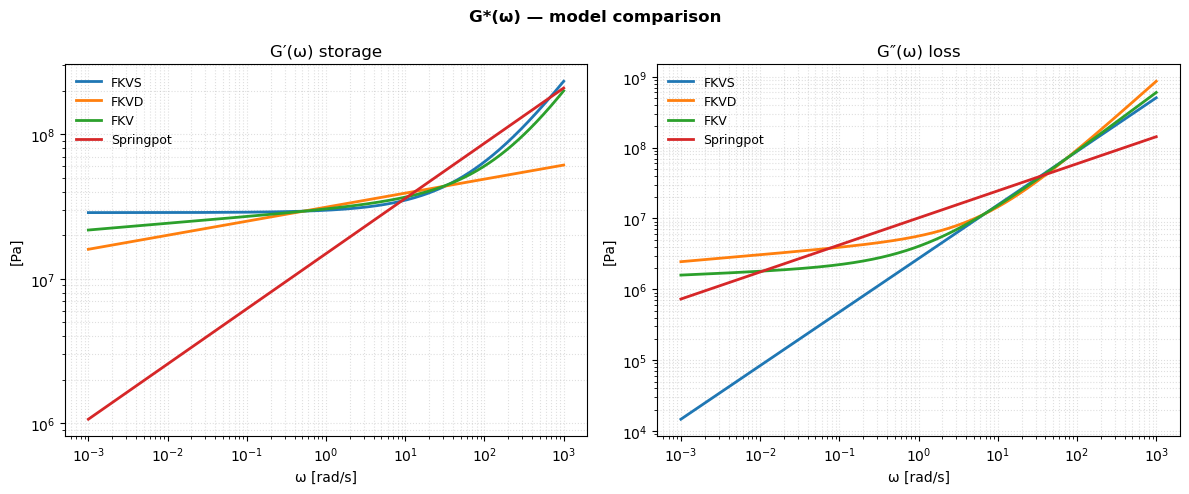

In [10]:
# compare models — now ranks by AIC or BIC, your choice
models = {}
for name in ["FKVS", "FKVD", "FKV", "Springpot"]:
    models[name] = SPGP(model=name, kernel="linear",          # NEW default: two-phase RBF→linear
                                           #   (keep kernel="rbf" for identical-to-before behavior)
             convolution="causal",         # NEW: or "steady" if your chirp is windowed
             quadrature="exact",           # NEW default (use "left" to reproduce v0.1 numbers)
             inducing_points=300, learning_rate=0.005, learning_rate_physics=0.005,
             omega_min=0.001, omega_max=1000, n_epochs=20000).fit(t, strain, stress)

best = compare_models(models, criterion="bic")   # or criterion="aic"

In [11]:
# --- Add GP input features: standardized (what GP sees) and raw (physical convolution) ---
import matplotlib.pyplot as plt

def _compute_raw_features(model):
    """
    Raw (unstandardized) convolution features x(t) for common models:
    Springpot, Fractional Maxwell (full, covers FMG/FML via params), Fractional Kelvin–Voigt (full).
    Also supports FKVS/FKVD second branch (γ or γ̇) when those kernels are used.
    Returns: t (N,), X_raw (N, d), labels (list[str])
    """
    import numpy as np
    import torch
    import rheogp.kernels as rk

    phys = model.gp_model_.phys
    t = model.t_.astype(np.float64)
    dt = float(np.median(np.diff(t)))
    gamma = torch.tensor(model.strain_, dtype=torch.float64)

    # Common helpers
    s = rk._lag_vector(gamma.shape[0], dt, device=gamma.device, dtype=gamma.dtype)
    gd = rk._gamma_dot(gamma, dt)  # γ̇(t)

    X_cols, labels = [], []

    # Springpot
    if isinstance(phys, rk.SpringpotKernel):
        alpha = torch.tensor(phys.alpha.item(), dtype=gamma.dtype)
        K = rk._caputo_kernel(s, alpha)
        x = rk._fft_convolve(gd, K, dt)
        X_cols.append(x.detach().cpu().numpy()); labels.append(r"D$^{\alpha}[\gamma]$ (s$^{-\alpha}$)")

    # Fractional Maxwell (full; FMG/FML via parameters)
    elif isinstance(phys, rk.FractionalMaxwellKernel):
        alpha = torch.tensor(phys.alpha.item(), dtype=gamma.dtype)
        beta  = torch.tensor(phys.beta.item(),  dtype=gamma.dtype)
        tau_c = torch.tensor(phys.tau_c.item(), dtype=gamma.dtype)
        K = rk._fmm_kernel(s, alpha, beta, tau_c)
        x = rk._fft_convolve(gd, K, dt)
        X_cols.append(x.detach().cpu().numpy()); labels.append(r"K$_{\mathrm{FMM}} \star \dot{\gamma}$ (–)")

    # Fractional Kelvin–Voigt (full)
    elif isinstance(phys, rk.FractionalKelvinVoigtKernel):
        alpha = torch.tensor(phys.alpha.item(), dtype=gamma.dtype)
        beta  = torch.tensor(phys.beta.item(),  dtype=gamma.dtype)
        Ka = rk._caputo_kernel(s, alpha)
        Kb = rk._caputo_kernel(s, beta)
        xa = rk._fft_convolve(gd, Ka, dt)
        xb = rk._fft_convolve(gd, Kb, dt)
        X_cols.append(xa.detach().cpu().numpy()); labels.append(r"D$^{\alpha}[\gamma]$ (s$^{-\alpha}$)")
        X_cols.append(xb.detach().cpu().numpy()); labels.append(r"D$^{\beta}[\gamma]$ (s$^{-\beta}$)")

    # Fractional Kelvin–Voigt S (springpot ∥ spring): [D^αγ, γ]
    elif isinstance(phys, rk.FKVSKernel):
        alpha = torch.tensor(phys.alpha.item(), dtype=gamma.dtype)
        Ka = rk._caputo_kernel(s, alpha)
        xa = rk._fft_convolve(gd, Ka, dt)           # D^α[γ]
        x0 = gamma                                  # γ
        X_cols.append(xa.detach().cpu().numpy()); labels.append(r"D$^{\alpha}[\gamma]$ (s$^{-\alpha}$)")
        X_cols.append(x0.detach().cpu().numpy());  labels.append(r"$\gamma$ (–)")

    # Fractional Kelvin–Voigt D (dashpot ∥ springpot): [D^βγ, γ̇]
    elif isinstance(phys, rk.FKVDKernel):
        beta = torch.tensor(phys.beta.item(), dtype=gamma.dtype)
        Kb = rk._caputo_kernel(s, beta)
        xb = rk._fft_convolve(gd, Kb, dt)           # D^β[γ]
        x1 = gd                                     # γ̇
        X_cols.append(xb.detach().cpu().numpy()); labels.append(r"D$^{\beta}[\gamma]$ (s$^{-\beta}$)")
        X_cols.append(x1.detach().cpu().numpy()); labels.append(r"$\dot{\gamma}$ (s$^{-1}$)")

    # Maxwell (classical): [exp kernel ★ γ̇]
    elif isinstance(phys, rk.MaxwellKernel):
        tau_c = torch.tensor(phys.tau_c.item(), dtype=gamma.dtype)
        Km = rk._maxwell_kernel(s, tau_c)
        x = rk._fft_convolve(gd, Km, dt)
        X_cols.append(x.detach().cpu().numpy()); labels.append(r"exp kernel $\star \dot{\gamma}$ (–)")

    else:
        # Fallback: use whatever compute_x() returned (but that is standardized)
        raise NotImplementedError(f"Raw features not implemented for {type(phys).__name__}")

    X_raw = np.vstack(X_cols).T  # (N, d)
    return t, X_raw, labels

# Standardized GP inputs (unitless)
X_norm = model.gp_model_.compute_x().detach().cpu().numpy()  # (N, d)

# Raw features (with physical units; see labels)
try:
    X_time, X_raw, X_labels = _compute_raw_features(model)
except Exception as e:
    print(f"Warning: could not compute raw features: {e}")
    X_time, X_raw, X_labels = model.t_, None, []

# Optional: quick figure overlaying strain on each raw feature
try:
    if X_raw is not None and X_raw.size:
        rows = X_raw.shape[1]
        fig_feat, ax = plt.subplots(rows, 1, figsize=(7, 2.6 * rows), sharex=True)
        if rows == 1: ax = [ax]
        for j in range(rows):
            ax[j].plot(X_time, X_raw[:, j], lw=1.5, label=X_labels[j] if j < len(X_labels) else f"x{j}")
            ax[j].set_ylabel(X_labels[j] if j < len(X_labels) else f"x{j}")
            ax2 = ax[j].twinx()
            ax2.plot(model.t_, model.strain_, 'k--', lw=1.1, alpha=0.8, label="γ(t)")
            ax2.set_ylabel("γ (–)")
            # Combined legend
            l1, lab1 = ax[j].get_legend_handles_labels()
            l2, lab2 = ax2.get_legend_handles_labels()
            ax[j].legend(l1 + l2, lab1 + lab2, loc="best")
            ax[j].grid(alpha=0.2)
        ax[-1].set_xlabel("t (s)")
        fig_feat.tight_layout()
        fig_feat.savefig("features_raw.pdf", bbox_inches="tight")
        fig_feat.savefig("features_raw.png", dpi=300, bbox_inches="tight")
        plt.close(fig_feat)
except Exception as e:
    print(f"Warning: feature plot failed: {e}")

# ---------- Save results (arrays + metadata) and figures ----------
from pathlib import Path
import numpy as np
import json
import matplotlib.pyplot as plt

# 6) Save arrays (compressed NPZ)
omega_curve = np.logspace(np.log10(model.omega_min),
                          np.log10(model.omega_max), model.n_omega)
scalar_pf   = {k: v["scalar_mean"] for k, v in model.prefactors_.items()}
Gp_curve, Gdp_curve = model.gp_model_.phys.Gstar(omega_curve, scalar_pf)

# 2) FFT dots (no plotting)
omega_fft, Gp_fft, Gdp_fft = model._chirp_fft_Gstar(eps=1e-12)
mask = (omega_fft >= model.omega_min) & (omega_fft <= model.omega_max)
omega_fft, Gp_fft, Gdp_fft = omega_fft[mask], Gp_fft[mask], Gdp_fft[mask]

# 3) Prefactors summary + (optional) samples
pref_summary = {
    name: {
        "mean":    info["mean"].tolist(),
        "lower":   info["lower"].tolist(),
        "upper":   info["upper"].tolist(),
        "scalar_mean":  info["scalar_mean"],
        "scalar_lower": info["scalar_lower"],
        "scalar_upper": info["scalar_upper"],
    }
    for name, info in model.prefactors_.items()
}

# Optional: include posterior samples (can be large)
include_samples = True
if include_samples:
    for name, info in model.prefactors_.items():
        pref_summary[name]["samples"] = info["samples"]  # keep as ndarray for .npz

# 4) Serializable metadata
meta = {
    "model_name": model.model_name,
    "kernel_name": model.kernel_name,
    "omega_min": model.omega_min,
    "omega_max": model.omega_max,
    "n_omega": model.n_omega,
    "phys_params": model.gp_model_.phys.named_phys_params(),
    "metrics": model.metrics_,
}

# 5) Training history (loss and tracked physics params)
history = {
    "loss": model.history_.get("loss", []),
    "params": model.history_.get("params", {}),
}

# 5) Save arrays in a compressed NPZ; save metadata (and prefactors summary) as JSON
out_dir = Path("outputs_photopolymer")
out_dir.mkdir(parents=True, exist_ok=True)

arrays = dict(
    time=model.t_,
    strain=model.strain_,
    stress=model.stress_,
    pred=sigma_pred,
    pred_std=sigma_std,
    omega_curve=omega_curve,
    Gp_curve=Gp_curve,
    Gdp_curve=Gdp_curve,
    omega_fft=omega_fft,
    Gp_fft=Gp_fft,
    Gdp_fft=Gdp_fft,
    # Added: features
    X_time=X_time if X_raw is not None else model.t_,
    X_norm=X_norm,                          # standardized GP inputs (unitless)
    X_raw=X_raw if X_raw is not None else np.array([]),  # raw features (physical units)
)

# Optional: add prefactor samples (already in your code when include_samples=True)
if include_samples:
    for name, info in model.prefactors_.items():
        arrays[f"pref_{name}_samples"] = info["samples"]
        
np.savez_compressed(out_dir / "rheogp_arrays.npz", **arrays)

# 7) Save metadata (JSON)
meta = {
    "model_name": model.model_name,
    "kernel_name": model.kernel_name,
    "inducing_points": model.inducing_points,
    "learning_rate": model.learning_rate,
    "omega_min": model.omega_min,
    "omega_max": model.omega_max,
    "n_omega": model.n_omega,
    "phys_params": {k: float(v) for k, v in model.gp_model_.phys.named_phys_params().items()},  # Ensure floats
    "metrics": {k: float(v) for k, v in model.metrics_.items() if not isinstance(v, dict)},  # Ensure floats
    "prefactors": {
        name: {
            "mean": info["mean"] if isinstance(info["mean"], list) else info["mean"].tolist(),
            "lower": info["lower"] if isinstance(info["lower"], list) else info["lower"].tolist(),
            "upper": info["upper"] if isinstance(info["upper"], list) else info["upper"].tolist(),
            "scalar_mean": float(info["scalar_mean"]),
            "scalar_lower": float(info["scalar_lower"]),
            "scalar_upper": float(info["scalar_upper"]),
        }
        for name, info in pref_summary.items()
    },
    "history": {
        "loss": list(history["loss"]),
        "tracked_params": {
            k: list(v) for k, v in history["params"].items()  # Ensure lists
        },
    },
    "X_labels": list(X_labels) if isinstance(X_labels, np.ndarray) else X_labels,  # Convert ndarray to list
}


with open(out_dir / "rheogp_meta.json", "w") as f:
    json.dump(meta, f, indent=2)



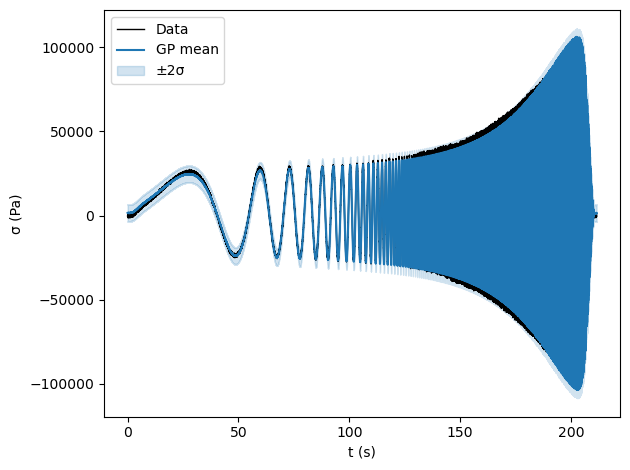

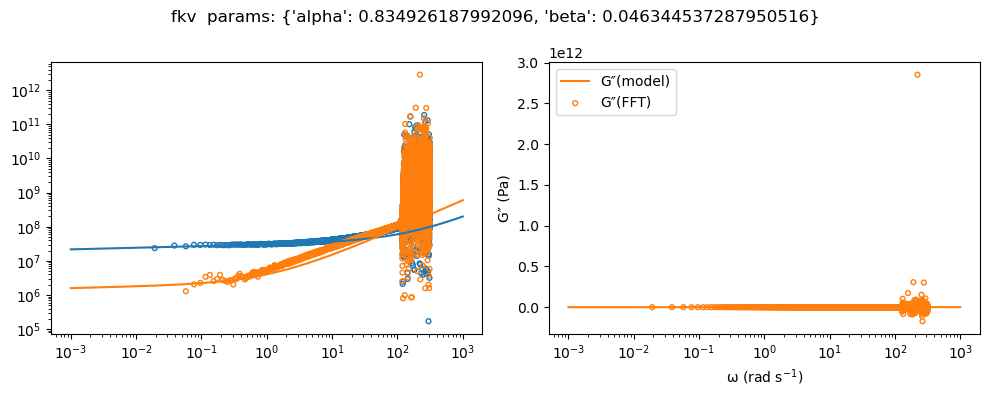

V: scalar_mean=1.931e+06 [1.929e+06, 1.933e+06]
G_bb: scalar_mean=2.999e+07 [2.995e+07, 3.002e+07]


In [12]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Load
arrs = np.load("outputs_photopolymer/rheogp_arrays.npz", allow_pickle=True)
with open("outputs_photopolymer/rheogp_meta.json") as f:
    meta = json.load(f)

# Time-domain fit
t = arrs["time"]; stress = arrs["stress"]; pred = arrs["pred"]; pred_std = arrs["pred_std"]
plt.figure()
plt.plot(t, stress, 'k-', lw=1, label='Data')
plt.plot(t, pred, 'C0-', lw=1.5, label='GP mean')
plt.fill_between(t, pred - 2*pred_std, pred + 2*pred_std, color='C0', alpha=0.2, label='±2σ')
plt.xlabel('t (s)'); plt.ylabel('σ (Pa)')
plt.legend(); plt.tight_layout(); plt.show()

# Frequency-domain: G′/G″ with FFT dots
omega = arrs["omega_curve"]; Gp = arrs["Gp_curve"]; Gdp = arrs["Gdp_curve"]
omega_f = arrs["omega_fft"]; Gp_f = arrs["Gp_fft"]; Gdp_f = arrs["Gdp_fft"]

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
for a in ax: a.set_xscale('log')
ax[0].plot(omega, Gp, 'C0-', label="G′(model)")
ax[0].scatter(omega_f, Gp_f, s=12, facecolors='none', edgecolors='C0', label='G′(FFT)')
ax[0].plot(omega, Gdp, 'C1-', label="G″(model)")
ax[0].scatter(omega_f, Gdp_f, s=12, facecolors='none', edgecolors='C1', label='G″(FFT)')
ax[0].set_yscale("log")
ax[0].set_xscale("log")

ax[1].plot(omega, Gdp, 'C1-', label="G″(model)")
ax[1].scatter(omega_f, Gdp_f, s=12, facecolors='none', edgecolors='C1', label='G″(FFT)')
ax[1].set_ylabel("G″ (Pa)"); ax[1].set_xlabel('ω (rad s$^{-1}$)'); ax[1].legend()

fig.suptitle(f"{meta['model_name']}  params: {meta['phys_params']}")
plt.tight_layout(); plt.show()

# Prefactor summaries
for name, info in meta["prefactors"].items():
    print(f"{name}: scalar_mean={info['scalar_mean']:.4g} "
          f"[{info['scalar_lower']:.4g}, {info['scalar_upper']:.4g}]")


In [13]:
"""
Residual autocorrelation and information criteria at the effective sample size
=============================================================================
Works directly on a dict of FITTED SPGP objects, as produced by

    models = {}
    for name in ["Maxwell", "FMG", "FML", "FMM", "Springpot"]:
        models[name] = SPGP(...).fit(t, strain, stress)

Reports, for every candidate and both at full N and at the effective
sample size N_eff, the two terms of each criterion separately:

    AIC = 2U + 2k                 BIC = 2U + k ln N
          ^--- fit    ^--- penalty

so that it is visible which term the correlation correction acts on.

USAGE
-----
    import residual_neff as rn
    rows = rn.analyze_models(models, stress, label="wormlike micelles")
    rn.plot_residuals(rows, t)
"""

import numpy as np
import matplotlib.pyplot as plt


# --------------------------------------------------------- autocorrelation
def acf(x, nlags=None):
    """Normalized autocorrelation of a 1-D sequence, lags 0..nlags."""
    x = np.asarray(x, float)
    x = x - x.mean()
    n = x.size
    if nlags is None:
        nlags = min(n - 1, 5000)
    nfft = 1 << int(np.ceil(np.log2(2 * n)))          # zero-pad: no circular wrap
    f = np.fft.rfft(x, nfft)
    r = np.fft.irfft(f * np.conj(f), nfft)[:nlags + 1].real
    return r / r[0]


def tau_int(rho):
    """
    Integrated autocorrelation time by Geyer's initial-positive-sequence rule:
    accumulate consecutive lag PAIRS while their sum stays positive.

    The pairwise truncation is essential for oscillatory residuals, whose
    raw ACF rings indefinitely; a naive sum would diverge or go negative.
    """
    s, k = 0.0, 1
    while k + 1 < rho.size:
        pair = rho[k] + rho[k + 1]
        if pair <= 0:
            break
        s += pair
        k += 2
    return max(1.0 + 2.0 * s, 1.0), k


# ------------------------------------------------------------- main routine
def analyze_models(models, stress, label="", nlags=5000):
    """
    models : dict {name: fitted SPGP}
    stress : the measured stress array used for training
    """
    stress = np.asarray(stress, float)
    rows = []

    for name, m in models.items():
        resid = stress - np.asarray(m.pred_, float)
        N     = resid.size
        rho   = acf(resid, min(nlags, N - 1))
        tau, kcut = tau_int(rho)
        N_eff = N / tau

        U = m.metrics_["nll"]                       # total negative ELBO
        k = m.metrics_["n_params"]["k_total"]

        # --- full N -------------------------------------------------------
        fit_N      = 2.0 * U
        pen_aic_N  = 2.0 * k
        pen_bic_N  = k * np.log(N)

        # --- effective N --------------------------------------------------
        # U = N*u with u the per-point bound; rescale to U_eff = N_eff*u
        U_eff       = U * (N_eff / N)
        fit_eff     = 2.0 * U_eff
        pen_aic_eff = 2.0 * k                        # AIC penalty is N-free
        pen_bic_eff = k * np.log(N_eff)

        rows.append(dict(
            model=name, N=N, tau=tau, N_eff=N_eff, kcut=kcut, k=k,
            rmse=float(np.sqrt((resid ** 2).mean())),
            fit_N=fit_N, pen_aic_N=pen_aic_N, pen_bic_N=pen_bic_N,
            aic_N=fit_N + pen_aic_N, bic_N=fit_N + pen_bic_N,
            fit_eff=fit_eff, pen_aic_eff=pen_aic_eff, pen_bic_eff=pen_bic_eff,
            aic_eff=fit_eff + pen_aic_eff, bic_eff=fit_eff + pen_bic_eff,
            resid=resid, rho=rho))

    # deltas relative to the best candidate under each criterion
    for key, dkey in (("aic_N", "daic_N"), ("bic_N", "dbic_N"),
                      ("aic_eff", "daic_eff"), ("bic_eff", "dbic_eff")):
        best = min(r[key] for r in rows)
        for r in rows:
            r[dkey] = r[key] - best

    rows.sort(key=lambda r: r["dbic_N"])
    _print_table(rows, label)
    return rows


def _print_table(rows, label):
    print(f"\n=== {label} : autocorrelation and effective sample size ===")
    print(f"{'model':10s} {'N':>7s} {'tau_int':>8s} {'N_eff':>9s} {'k':>3s} "
          f"{'RMSE':>10s}")
    for r in rows:
        print(f"{r['model']:10s} {r['N']:7d} {r['tau']:8.1f} {r['N_eff']:9.1f} "
              f"{r['k']:3d} {r['rmse']:10.4g}")

    print(f"\n--- criterion terms at FULL N ---")
    print(f"{'model':10s} {'2U':>12s} {'2k':>8s} {'k lnN':>9s} "
          f"{'AIC':>12s} {'BIC':>12s} {'dAIC':>9s} {'dBIC':>9s}")
    for r in rows:
        print(f"{r['model']:10s} {r['fit_N']:12.1f} {r['pen_aic_N']:8.1f} "
              f"{r['pen_bic_N']:9.1f} {r['aic_N']:12.1f} {r['bic_N']:12.1f} "
              f"{r['daic_N']:9.1f} {r['dbic_N']:9.1f}")

    print(f"\n--- criterion terms at EFFECTIVE N ---")
    print(f"{'model':10s} {'2U_eff':>12s} {'2k':>8s} {'k lnNeff':>9s} "
          f"{'AIC_eff':>12s} {'BIC_eff':>12s} {'dAIC_eff':>9s} {'dBIC_eff':>9s}")
    for r in rows:
        print(f"{r['model']:10s} {r['fit_eff']:12.1f} {r['pen_aic_eff']:8.1f} "
              f"{r['pen_bic_eff']:9.1f} {r['aic_eff']:12.1f} "
              f"{r['bic_eff']:12.1f} {r['daic_eff']:9.1f} {r['dbic_eff']:9.1f}")


# ------------------------------------------------------------------ figure
def plot_residuals(rows, t, which=None):
    """Residual trace and ACF for one model (default: best by BIC at full N)."""
    r = rows[0] if which is None else next(x for x in rows if x["model"] == which)
    t = np.asarray(t, float)

    fig, ax = plt.subplots(1, 2, figsize=(6.2, 2.4))
    ax[0].plot(t, r["resid"], "o", ms=1, alpha=0.5, color="tab:orange",
               rasterized=True)
    ax[0].axhline(0, color="k", lw=0.8)
    ax[0].set_xlabel("$t$ [s]")
    ax[0].set_ylabel(r"$\sigma-\bar{\sigma}$ [Pa]")

    lags = np.arange(r["rho"].size)
    ax[1].plot(lags, r["rho"], "-", color="tab:blue", lw=1.0)
    ax[1].axhline(0, color="k", lw=0.8)
    ax[1].axvline(r["kcut"], color="k", lw=0.6, ls="--",
                  label=f"truncation lag {r['kcut']}")
    ax[1].set_xlabel("lag [samples]")
    ax[1].set_ylabel(r"$\rho_k$")
    ax[1].set_xlim(0, min(4 * r["kcut"] + 20, r["rho"].size))
    ax[1].legend(frameon=False, fontsize=6)
    for a in ax:
        a.grid(False)
    fig.suptitle(f"{r['model']}:  " r"$\tau_{\rm int}=$" f"{r['tau']:.0f},  "
                 r"$N_{\rm eff}=$" f"{r['N_eff']:.0f}", fontsize=8)
    fig.tight_layout()
    plt.show()
    return fig


=== wormlike micelles : autocorrelation and effective sample size ===
model            N  tau_int     N_eff   k       RMSE
FKV          32689      3.2   10079.3   8       2439
FKVS         32689      3.2   10102.1   7       2671
FKVD         32689    469.2      69.7   7       2875
Springpot    32689    742.6      44.0   6  1.104e+04

--- criterion terms at FULL N ---
model                2U       2k     k lnN          AIC          BIC      dAIC      dBIC
FKV            -73134.4     16.0      83.2     -73118.4     -73051.2       0.0       0.0
FKVS           -67272.5     14.0      72.8     -67258.5     -67199.7    5859.9    5851.5
FKVD           -62536.9     14.0      72.8     -62522.9     -62464.1   10595.4   10587.0
Springpot       25003.5     12.0      62.4      25015.5      25065.8   98133.8   98117.0

--- criterion terms at EFFECTIVE N ---
model            2U_eff       2k  k lnNeff      AIC_eff      BIC_eff  dAIC_eff  dBIC_eff
FKV            -22550.2     16.0      73.7     -22534.2

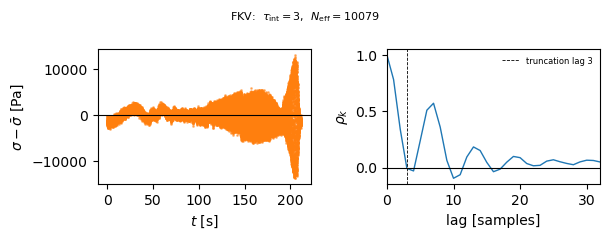

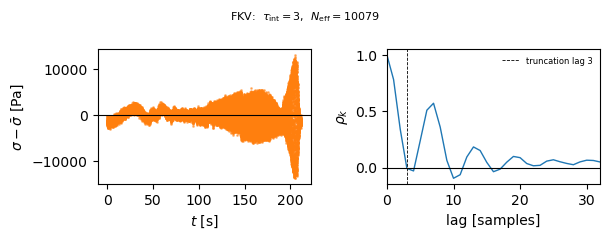

In [14]:
rows = analyze_models(models, stress, label="wormlike micelles")
plot_residuals(rows, t)